# 📊 Sales Performance Analysis using SQL

## 👨‍💻 By Himanshu Nangwal

### 🎯 Objective:
To analyze retail sales data using SQL and extract insights related to sales, profit, customer performance, and product trends.

In [5]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("SuperStore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

## 1. Data Loading and Cleaning

In [9]:
df.info()
df.isnull().sum()
df = df.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

In [11]:
df["Month"] = df["Order Date"].dt.month

## 2. Creating SQL Database"

In [12]:
conn = sqlite3.connect("superstore_sales.db")
df.to_sql("sales", conn, if_exists="replace", index=False)

9994

In [13]:
pd.read_sql("SELECT * FROM sales LIMIT 5", conn)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month
0,1,CA-2016-152156,2016-11-08 00:00:00,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11
1,2,CA-2016-152156,2016-11-08 00:00:00,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11
2,3,CA-2016-138688,2016-06-12 00:00:00,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6
3,4,US-2015-108966,2015-10-11 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10
4,5,US-2015-108966,2015-10-11 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10


## 3. SQL Analysis

### Total Sales

This query calculates the total revenue generated by the business.

In [15]:
query = """
SELECT SUM(Sales) AS Total_Sales
FROM sales
"""
pd.read_sql(query, conn)

,Total_Sales
0,2.297201e+06


**Insight:**  
This gives the total sales generated across all orders in the dataset.

### Total Profit

This query calculates the overall profit earned by the business.

In [16]:
query = """
SELECT SUM(Profit) AS Total_Profit
FROM sales
"""
pd.read_sql(query, conn)

,Total_Profit
0,286397.0217


**Insight:**  
This shows the total profit after all sales transactions.

### Sales by Region

This query analyzes which region contributes the most to total sales.

In [18]:
query = """
SELECT Region, SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC
"""
region_sales = pd.read_sql(query, conn)
region_sales

,Region,Total_Sales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


**Insight:**  
This helps identify the highest-performing and lowest-performing sales regions.

### Profit by Category

This query shows which product category generates the highest profit.

In [20]:
query = """
SELECT Category, SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Category
ORDER BY Total_Profit DESC
"""
category_profit = pd.read_sql(query, conn)
category_profit

,Category,Total_Profit
0,Technology,145454.9481
1,Office Supplies,122490.8008
2,Furniture,18451.2728


**Insight:**  
This helps understand category-wise profitability and business performance.

### Top 10 Products by Sales

This query identifies the products that generate the highest sales.

In [22]:
query = """
SELECT "Product Name", SUM(Sales) AS Total_Sales
FROM sales
GROUP BY "Product Name"
ORDER BY Total_Sales DESC
LIMIT 10
"""
top_products = pd.read_sql(query, conn)
top_products

,Product Name,Total_Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


**Insight:**  
A small number of products contribute significantly to total revenue.

### Top 10 Customers by Sales

This query identifies the customers contributing the highest sales.

In [23]:
query = """
SELECT "Customer Name", SUM(Sales) AS Total_Sales
FROM sales
GROUP BY "Customer Name"
ORDER BY Total_Sales DESC
LIMIT 10
"""
top_customers = pd.read_sql(query, conn)
top_customers

,Customer Name,Total_Sales
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


### Sales by Ship Mode

This query analyzes sales distribution across different shipping modes.

In [24]:
query = """
SELECT "Ship Mode", SUM(Sales) AS Total_Sales
FROM sales
GROUP BY "Ship Mode"
ORDER BY Total_Sales DESC
"""
ship_mode_sales = pd.read_sql(query, conn)
ship_mode_sales

,Ship Mode,Total_Sales
0,Standard Class,1.358216e+06
1,Second Class,4.591936e+05
2,First Class,3.514284e+05
3,Same Day,1.283631e+05


**Insight:**  
This helps understand which shipping mode is associated with the highest sales.

### Monthly Sales Trend

This query analyzes sales trends across different months.

In [26]:
query = """
SELECT Month, SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Month
ORDER BY Month
"""
monthly_sales = pd.read_sql(query, conn)
monthly_sales

,Month,Total_Sales
0,1,94924.8356
1,2,59751.2514
2,3,205005.4888
3,4,137762.1286
4,5,155028.8117
5,6,152718.6793
6,7,147238.0970
7,8,159044.0630
8,9,307649.9457
9,10,200322.9847


**Insight:**  
This shows how sales vary month by month and highlights seasonal patterns.

## 4. Data Visualization

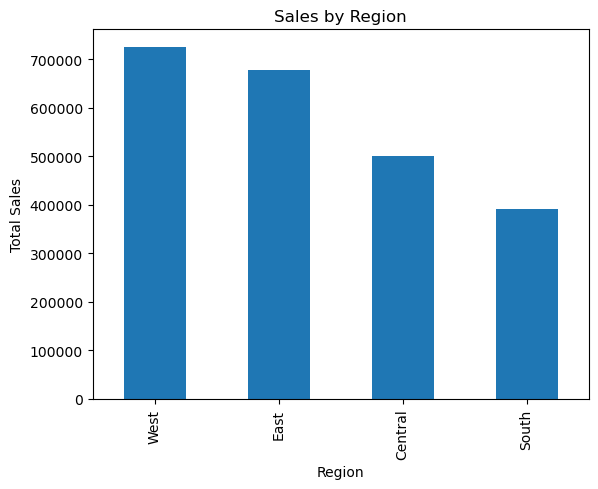

In [27]:
region_sales.plot(x="Region", y="Total_Sales", kind="bar", legend=False)
plt.title("Sales by Region")
plt.ylabel("Total Sales")
plt.show()

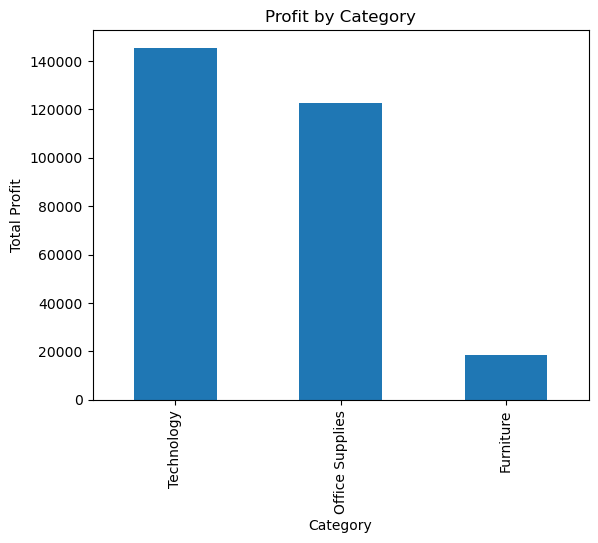

In [28]:
category_profit.plot(x="Category", y="Total_Profit", kind="bar", legend=False)
plt.title("Profit by Category")
plt.ylabel("Total Profit")
plt.show()

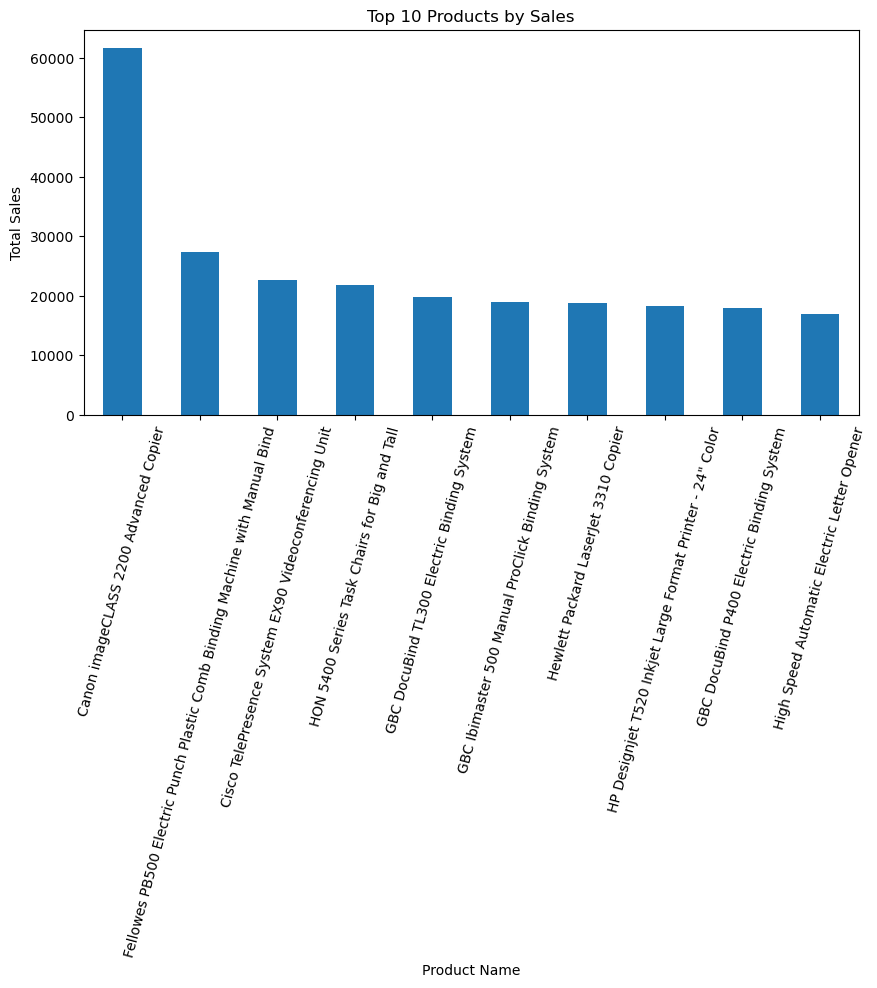

In [29]:
top_products.plot(x="Product Name", y="Total_Sales", kind="bar", legend=False, figsize=(10,5))
plt.title("Top 10 Products by Sales")
plt.ylabel("Total Sales")
plt.xticks(rotation=75)
plt.show()

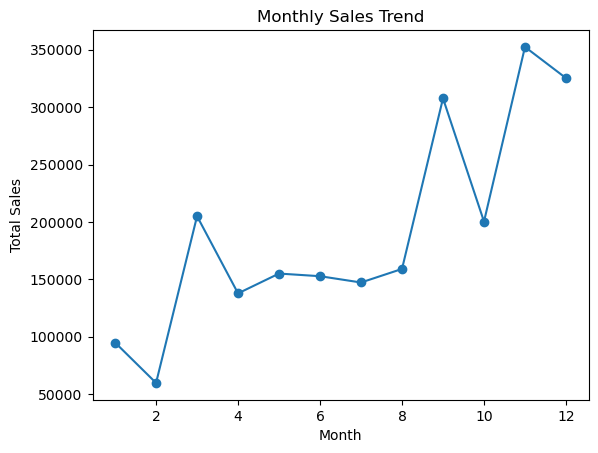

In [31]:
monthly_sales.plot(x="Month", y="Total_Sales", kind="line", marker="o", legend=False)
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales")
plt.show()

## 5. Conclusion

- The project analyzed retail sales data using SQL and Python.
- Region-wise analysis helped identify the strongest sales areas.
- Category-wise profit analysis showed which business segments are most profitable.
- Top products and customers contributed significantly to overall revenue.
- Monthly sales trends showed fluctuations and possible seasonal patterns.

### Business Recommendations:
- Focus marketing efforts on high-performing products and customers.
- Improve performance in low-performing regions.
- Use monthly sales patterns for better planning and forecasting.

In [32]:
conn.close()